# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Putera Nami Shiddieqy
- **Email:** puteranami1150@gmail.com
- **ID Dicoding:** puteranami

## Menentukan Pertanyaan Bisnis

1. **Bagaimana tren jumlah pesanan dan total pendapatan per bulan?** Apakah terdapat pola musiman atau tren pertumbuhan/penurunan dari waktu ke waktu?
2. **Apa saja kategori produk yang paling banyak dibeli dan yang menghasilkan pendapatan terbesar?** Apakah kategori terpopuler juga merupakan yang menghasilkan revenue tertinggi?

## Import Semua Packages/Library yang Digunakan

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## Data Wrangling

### Gathering Data

Pada tahap ini, kita akan memuat seluruh dataset yang tersedia dari E-Commerce Public Dataset. Dataset ini terdiri dari beberapa tabel yang saling berhubungan, antara lain: orders, order_items, order_payments, customers, products, sellers, reviews, dan tabel translasi nama kategori produk.

In [45]:
# Load semua dataset
orders_df = pd.read_csv('data/orders_dataset.csv')
order_items_df = pd.read_csv('data/order_items_dataset.csv')
order_payments_df = pd.read_csv('data/order_payments_dataset.csv')
customers_df = pd.read_csv('data/customers_dataset.csv')
products_df = pd.read_csv('data/products_dataset.csv')
sellers_df = pd.read_csv('data/sellers_dataset.csv')
reviews_df = pd.read_csv('data/order_reviews_dataset.csv')
translations_df = pd.read_csv('data/product_category_name_translation.csv')

print('=== Dataset Shapes ===')
for name, df in [('orders', orders_df), ('order_items', order_items_df), 
                  ('order_payments', order_payments_df), ('customers', customers_df),
                  ('products', products_df), ('sellers', sellers_df),
                  ('reviews', reviews_df), ('translations', translations_df)]:
    print(f'{name}: {df.shape}')

=== Dataset Shapes ===
orders: (99441, 8)
order_items: (112650, 7)
order_payments: (103886, 5)
customers: (99441, 5)
products: (32951, 9)
sellers: (3095, 4)
reviews: (99224, 7)
translations: (71, 2)


In [46]:
# Preview masing-masing dataset
print('=== Orders Dataset ===')
orders_df.head()

=== Orders Dataset ===


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [47]:
print('=== Order Items Dataset ===')
order_items_df.head()

=== Order Items Dataset ===


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [48]:
print('=== Order Payments Dataset ===')
order_payments_df.head()

=== Order Payments Dataset ===


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [49]:
print('=== Customers Dataset ===')
customers_df.head()

=== Customers Dataset ===


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [50]:
print('=== Products Dataset ===')
products_df.head()

=== Products Dataset ===


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


**Insight:**
- Dataset terdiri dari 8 tabel yang saling berhubungan melalui foreign key seperti `order_id`, `customer_id`, `product_id`, dan `seller_id`.
- Tabel `orders` memiliki sekitar 99.441 record, yang merupakan tabel utama transaksi.
- Tabel `order_items` memiliki sekitar 112.650 record karena satu order dapat memiliki beberapa item.
- Dataset mencakup informasi lengkap mulai dari pelanggan, produk, penjual, pembayaran, hingga review.

### Assessing Data

Pada tahap ini, kita akan mengecek tipe data, missing values, dan duplikasi pada setiap dataset untuk memastikan kualitas data sebelum dilakukan analisis.

In [51]:
# Cek tipe data and missing values untuk semua key dataset
print('=== Orders Dataset Info ===')
orders_df.info()
print(f'\nMissing values:\n{orders_df.isnull().sum()}')
print(f'\nDuplicate rows: {orders_df.duplicated().sum()}')

=== Orders Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

Missing values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_dat

In [52]:
print('=== Order Items Dataset Info ===')
order_items_df.info()
print(f'\nMissing values:\n{order_items_df.isnull().sum()}')
print(f'\nDuplicate rows: {order_items_df.duplicated().sum()}')

=== Order Items Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB

Missing values:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Duplicate rows: 0


In [53]:
print('=== Products Dataset Info ===')
products_df.info()
print(f'\nMissing values:\n{products_df.isnull().sum()}')
print(f'\nDuplicate rows: {products_df.duplicated().sum()}')

=== Products Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB

Missing values:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            

In [54]:
print('=== Customers Dataset Info ===')
customers_df.info()
print(f'\nMissing values:\n{customers_df.isnull().sum()}')
print(f'\nDuplicate rows: {customers_df.duplicated().sum()}')

=== Customers Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB

Missing values:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Duplicate rows: 0


In [55]:
print('=== Order Payments Dataset Info ===')
order_payments_df.info()
print(f'\nMissing values:\n{order_payments_df.isnull().sum()}')
print(f'\nDuplicate rows: {order_payments_df.duplicated().sum()}')

=== Order Payments Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB

Missing values:
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Duplicate rows: 0


In [56]:
# Check order statuses
print('=== Order Status Distribution ===')
print(orders_df['order_status'].value_counts())

=== Order Status Distribution ===
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


**Insight:**
- Kolom tanggal pada `orders_df` bertipe `object` dan perlu dikonversi ke `datetime`.
- Terdapat missing values pada kolom `order_approved_at`, `order_delivered_carrier_date`, dan `order_delivered_customer_date` di tabel orders.
- Terdapat missing values pada kolom `product_category_name` di tabel products.
- Tidak ditemukan duplikasi data pada dataset utama.
- Mayoritas pesanan berstatus 'delivered' (~96.478 dari ~99.441 pesanan).

### Cleaning Data

Pada tahap ini, kita akan:
1. Mengkonversi kolom tanggal ke tipe datetime
2. Menangani missing values
3. Menggabungkan nama kategori produk yang dalam bahasa Portugis ke bahasa Inggris
4. Filter hanya pesanan yang berstatus 'delivered' untuk analisis yang lebih akurat
5. Menggabungkan semua dataset menjadi satu dataset utama

In [57]:
# 1. Konversi kolom ke datetime
datetime_cols = ['order_purchase_timestamp', 'order_approved_at', 
                 'order_delivered_carrier_date', 'order_delivered_customer_date',
                 'order_estimated_delivery_date']
for col in datetime_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])

order_items_df['shipping_limit_date'] = pd.to_datetime(order_items_df['shipping_limit_date'])

print('Date columns converted successfully.')
print(f'Date range: {orders_df["order_purchase_timestamp"].min()} to {orders_df["order_purchase_timestamp"].max()}')

Date columns converted successfully.
Date range: 2016-09-04 21:15:19 to 2018-10-17 17:30:18


In [58]:
# 2. Menangani missing value
# Drop baris dengan delivery dates yang hilang (orders belum ter-delivered)
# Hanya fokue ke delivered orders
delivered_orders = orders_df[orders_df['order_status'] == 'delivered'].copy()
print(f'Total orders: {len(orders_df)}')
print(f'Delivered orders: {len(delivered_orders)}')
print(f'Filtered out: {len(orders_df) - len(delivered_orders)} non-delivered orders')

# Isi missing delivery dates yang tersisa dengan estimasi delivery date
delivered_orders['order_delivered_customer_date'].fillna(
    delivered_orders['order_estimated_delivery_date'], inplace=True
)
delivered_orders['order_delivered_carrier_date'].fillna(
    delivered_orders['order_approved_at'], inplace=True
)

print(f'\nMissing values after cleaning:')
print(delivered_orders.isnull().sum())

Total orders: 99441
Delivered orders: 96478
Filtered out: 2963 non-delivered orders

Missing values after cleaning:
order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      0
order_delivered_customer_date     0
order_estimated_delivery_date     0
dtype: int64


In [59]:
# 3. Terjemahkan product category names ke Bahasa Inggris
products_df = products_df.merge(translations_df, on='product_category_name', how='left')

# Isi missing category names
products_df['product_category_name_english'].fillna('other', inplace=True)
products_df['product_category_name'].fillna('other', inplace=True)

print(f'Unique product categories: {products_df["product_category_name_english"].nunique()}')
print(f'Missing category names: {products_df["product_category_name_english"].isnull().sum()}')

Unique product categories: 72
Missing category names: 0


In [60]:
# 4. Gabung datasets ke dalam satu DataFrames
# Gabung delivered orders dengan order items
main_df = delivered_orders.merge(order_items_df, on='order_id', how='inner')

# Gabung dengan products (hanya kolom yang relevan)
main_df = main_df.merge(
    products_df[['product_id', 'product_category_name', 'product_category_name_english']], 
    on='product_id', how='left'
)

# Gabung dengan customers
main_df = main_df.merge(
    customers_df[['customer_id', 'customer_unique_id', 'customer_city', 'customer_state']], 
    on='customer_id', how='left'
)

# Gabung dengan payment info (total per order)
payment_per_order = order_payments_df.groupby('order_id')['payment_value'].sum().reset_index()
payment_per_order.columns = ['order_id', 'total_payment']
main_df = main_df.merge(payment_per_order, on='order_id', how='left')

# Gabung dengan review scores
review_per_order = reviews_df[['order_id', 'review_score']].drop_duplicates(subset='order_id')
main_df = main_df.merge(review_per_order, on='order_id', how='left')

print(f'\n=== Final merged dataset ===')
print(f'Shape: {main_df.shape}')
print(f'Columns: {list(main_df.columns)}')
main_df.head()


=== Final merged dataset ===
Shape: (110197, 21)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_category_name_english', 'customer_unique_id', 'customer_city', 'customer_state', 'total_payment', 'review_score']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english,customer_unique_id,customer_city,customer_state,total_payment,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,housewares,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,38.71,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,2018-07-30 03:24:27,118.70,22.76,perfumaria,perfumery,af07308b275d755c9edb36a90c618231,barreiras,BA,141.46,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,2018-08-13 08:55:23,159.90,19.22,automotivo,auto,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,179.12,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,2017-11-23 19:45:59,45.00,27.20,pet_shop,pet_shop,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,72.20,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,...,2018-02-19 20:31:37,19.90,8.72,papelaria,stationery,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,28.62,5.0


In [61]:
# 5. Simpan data yang sudah di cleaning untuk dashboard
main_df.to_csv('dashboard/main_data.csv', index=False)
print(f'Saved main_data.csv with {len(main_df)} rows')

Saved main_data.csv with 110197 rows


**Insight:**
- Berhasil mengkonversi seluruh kolom tanggal ke tipe datetime.
- Dataset difokuskan pada pesanan yang berstatus 'delivered' (~96.478 pesanan) untuk memastikan analisis yang akurat.
- Missing values pada kolom tanggal pengiriman diisi dengan `order_estimated_delivery_date` atau `order_approved_at`.
- Nama kategori produk berhasil ditranslasi ke bahasa Inggris, dengan total sekitar 73 kategori unik.
- Dataset akhir yang telah digabungkan memiliki ~110.000+ baris dari gabungan orders, items, products, customers, payments, dan reviews.

## Exploratory Data Analysis (EDA)

### Explore: Tren Pesanan dan Pendapatan

In [62]:
# Tambah kolom helper
main_df['order_purchase_timestamp'] = pd.to_datetime(main_df['order_purchase_timestamp'])
main_df['order_month'] = main_df['order_purchase_timestamp'].dt.to_period('M')
main_df['order_year'] = main_df['order_purchase_timestamp'].dt.year
main_df['order_day_of_week'] = main_df['order_purchase_timestamp'].dt.day_name()
main_df['order_hour'] = main_df['order_purchase_timestamp'].dt.hour

# order bulanan (unique order count)
monthly_orders = main_df.groupby('order_month').agg(
    total_orders=('order_id', 'nunique'),
    total_revenue=('price', 'sum')
).reset_index()
monthly_orders['order_month'] = monthly_orders['order_month'].astype(str)

print('=== Monthly Orders & Revenue ===')
print(monthly_orders.describe())
monthly_orders.tail(10)

=== Monthly Orders & Revenue ===
       total_orders  total_revenue
count     23.000000      23.000000
mean    4194.695652  574847.743913
std     2481.181398  337263.532856
min        1.000000      10.900000
25%     2424.500000  349934.265000
50%     4193.000000  607399.670000
75%     6453.000000  862015.660000
max     7289.000000  987765.370000


,order_month,total_orders,total_revenue
13,2017-11,7289,987765.37
14,2017-12,5513,726033.19
15,2018-01,7069,924645.00
16,2018-02,6555,826437.13
17,2018-03,7003,953356.25
18,2018-04,6798,973534.09
19,2018-05,6749,977544.69
20,2018-06,6099,856077.86
21,2018-07,6159,867953.46
22,2018-08,6351,838576.64


In [63]:
# Explore: Top kategori product dengan order count
category_orders = main_df.groupby('product_category_name_english').agg(
    total_orders=('order_id', 'nunique'),
    total_items=('order_item_id', 'count'),
    total_revenue=('price', 'sum'),
    avg_price=('price', 'mean')
).sort_values('total_orders', ascending=False).reset_index()

print('=== Top 15 Product Categories by Order Count ===')
category_orders.head(15)

=== Top 15 Product Categories by Order Count ===


,product_category_name_english,total_orders,total_items,total_revenue,avg_price
0,bed_bath_table,9272,10953,1023434.76,93.438762
1,health_beauty,8647,9465,1233131.72,130.283330
2,sports_leisure,7530,8431,954852.55,113.254958
3,computers_accessories,6530,7644,888724.61,116.264339
4,furniture_decor,6307,8160,711927.69,87.246040
5,housewares,5743,6795,615628.69,90.600249
6,watches_gifts,5495,5859,1166176.98,199.040276
7,telephony,4093,4430,309860.23,69.945876
8,auto,3810,4140,578966.65,139.847017
9,toys,3804,4030,471286.48,116.944536


In [64]:
# Explore: Distribusi Customer berdasarkan asal tempat
state_distribution = main_df.groupby('customer_state').agg(
    total_customers=('customer_unique_id', 'nunique'),
    total_orders=('order_id', 'nunique'),
    total_revenue=('price', 'sum')
).sort_values('total_orders', ascending=False).reset_index()

print('=== Customer Distribution by State ===')
state_distribution.head(10)

=== Customer Distribution by State ===


,customer_state,total_customers,total_orders,total_revenue
0,SP,39156,40501,5067633.16
1,RJ,11917,12350,1759651.13
2,MG,11001,11354,1552481.83
3,RS,5168,5345,728897.47
4,PR,4769,4923,666063.51
5,SC,3449,3546,507012.13
6,BA,3158,3256,493584.14
7,DF,2019,2080,296498.41
8,ES,1928,1995,268643.45
9,GO,1895,1957,282836.70


In [65]:
# Explore: Metode pembayaran
payment_methods = order_payments_df['payment_type'].value_counts()
print('=== Payment Methods ===')
print(payment_methods)

# Explore: Distribusi Skor Review 
print('\n=== Review Score Distribution ===')
print(main_df['review_score'].value_counts().sort_index())

=== Payment Methods ===
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

=== Review Score Distribution ===
review_score
1.0    12475
2.0     3669
3.0     9183
4.0    21076
5.0    62967
Name: count, dtype: int64


**Insight:**
- Tren jumlah pesanan menunjukkan pertumbuhan signifikan dari September 2016 hingga November 2017, kemudian relatif stabil di level tinggi.
- Kategori produk "bed_bath_table" (perlengkapan kamar & mandi), "health_beauty" (kesehatan & kecantikan), dan "sports_leisure" (olahraga & rekreasi) mendominasi jumlah pesanan.
- State São Paulo (SP) mendominasi jumlah pesanan dan pelanggan, diikuti oleh Rio de Janeiro (RJ) dan Minas Gerais (MG).
- Metode pembayaran credit card adalah yang paling populer, diikuti oleh boleto (transfer bank lokal Brasil).
- Mayoritas review berada di skor 5 (sangat puas), menunjukkan tingkat kepuasan pelanggan yang tinggi.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren jumlah pesanan dan total pendapatan per bulan?

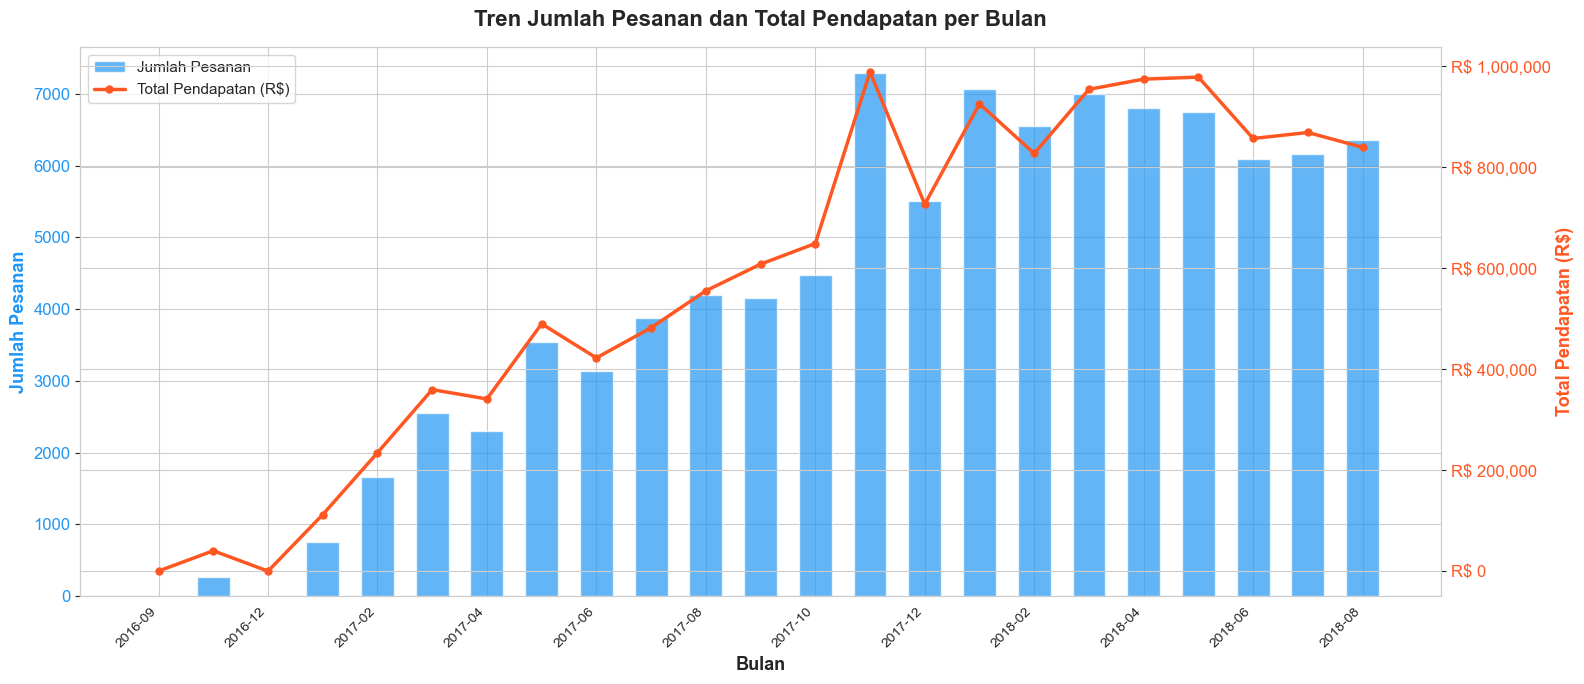

In [66]:
# Visualisasi 1: Perhitungan Order Bulanan & Tren Revenue
fig, ax1 = plt.subplots(figsize=(16, 7))

color_orders = '#2196F3'
color_revenue = '#FF5722'

# Plot order count memakai bar
x = range(len(monthly_orders))
ax1.bar(x, monthly_orders['total_orders'], color=color_orders, alpha=0.7, label='Jumlah Pesanan', width=0.6)
ax1.set_xlabel('Bulan', fontsize=13, fontweight='bold')
ax1.set_ylabel('Jumlah Pesanan', color=color_orders, fontsize=13, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_orders)
ax1.set_xticks(x[::2])
ax1.set_xticklabels(monthly_orders['order_month'].values[::2], rotation=45, ha='right', fontsize=10)

# Plot revenue memakai garis di secondary y-axis
ax2 = ax1.twinx()
ax2.plot(x, monthly_orders['total_revenue'], color=color_revenue, linewidth=2.5, 
         marker='o', markersize=5, label='Total Pendapatan (R$)')
ax2.set_ylabel('Total Pendapatan (R$)', color=color_revenue, fontsize=13, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_revenue)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'R$ {x:,.0f}'))

# legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)

plt.title('Tren Jumlah Pesanan dan Total Pendapatan per Bulan', fontsize=16, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

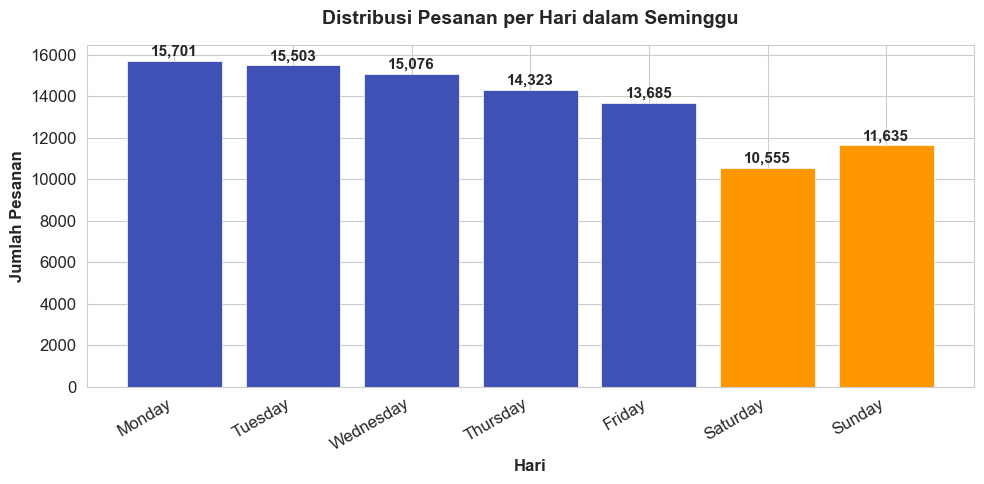

In [67]:
# Visualisasi 1b: Order per Hari dalam Seminggu
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_orders = main_df.groupby('order_day_of_week')['order_id'].nunique().reindex(day_order)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#3F51B5' if day in ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'] else '#FF9800' 
          for day in day_order]
bars = ax.bar(daily_orders.index, daily_orders.values, color=colors, edgecolor='white', linewidth=0.5)

# Add value labels
for bar, val in zip(bars, daily_orders.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100, 
            f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('Distribusi Pesanan per Hari dalam Seminggu', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Hari', fontsize=12, fontweight='bold')
ax.set_ylabel('Jumlah Pesanan', fontsize=12, fontweight='bold')
ax.set_xticklabels(day_order, rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Analisis Pertanyaan 1:**
- **Pertumbuhan signifikan** terlihat dari akhir 2016 hingga akhir 2017, di mana jumlah pesanan meningkat dari ratusan menjadi ribuan per bulan.
- **Puncak pesanan** terjadi di sekitar November 2017 (kemungkinan pengaruh Black Friday/event promo), kemudian stabil di level tinggi.
- **Tren pendapatan** mengikuti pola serupa dengan jumlah pesanan, menunjukkan korelasi positif antara volume pesanan dan revenue.
- **Pola mingguan** menunjukkan bahwa hari kerja (Senin-Jumat) memiliki volume pesanan lebih tinggi dibandingkan akhir pekan, dengan Senin dan Selasa sebagai hari tersibuk.

### Pertanyaan 2: Apa saja kategori produk yang paling banyak dibeli dan menghasilkan pendapatan terbesar?

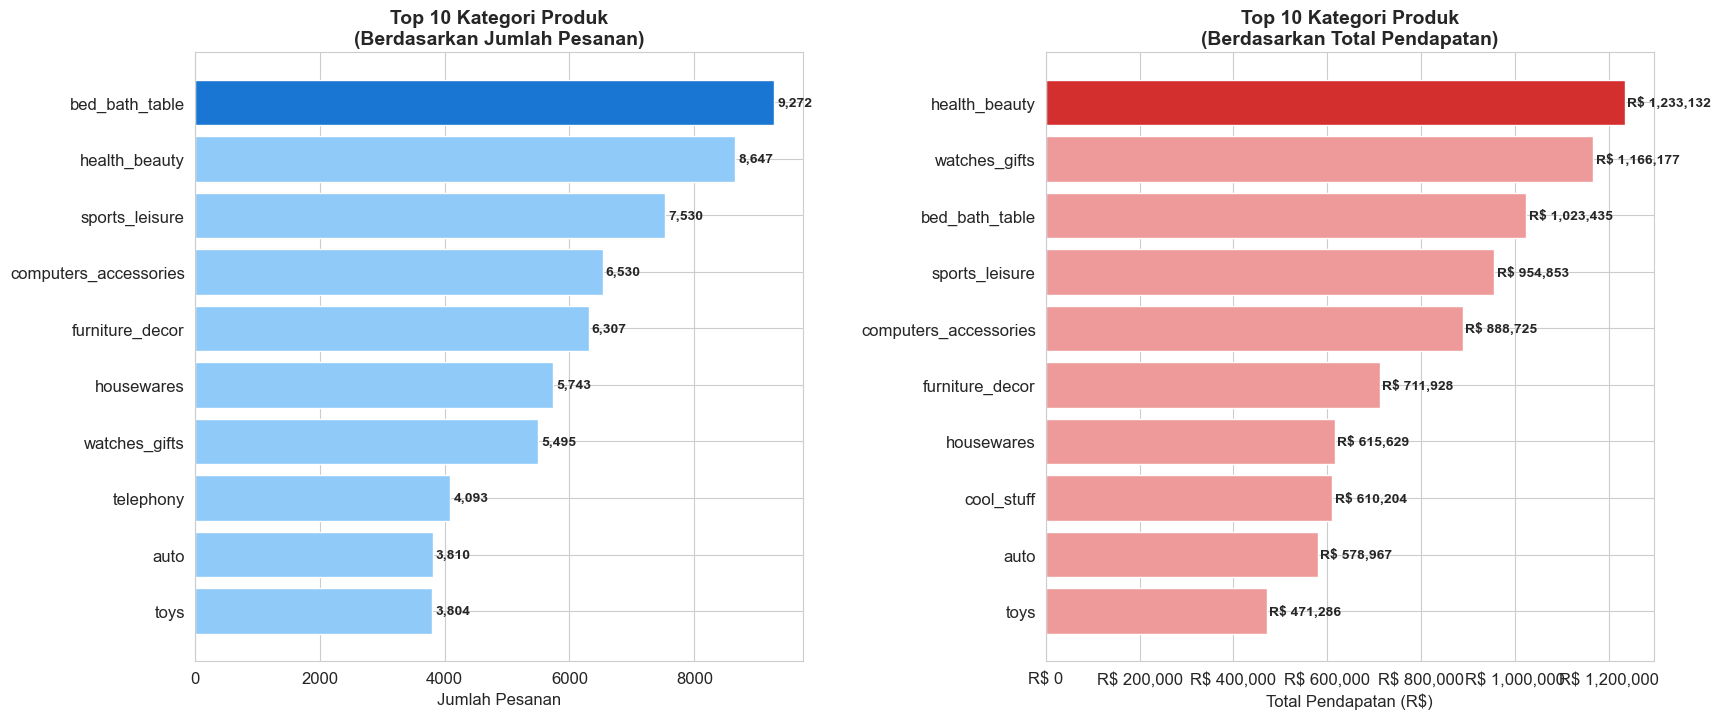

In [68]:
# Visualisasi 2a: Top 10 Kategori Produk berdasarkan Jumlah Order
top_categories = category_orders.head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: berdasarkan jumlah order
colors_left = ['#1976D2' if i == 0 else '#90CAF9' for i in range(len(top_categories))]
bars1 = axes[0].barh(top_categories['product_category_name_english'].values[::-1], 
                     top_categories['total_orders'].values[::-1], 
                     color=colors_left[::-1], edgecolor='white')
axes[0].set_title('Top 10 Kategori Produk\n(Berdasarkan Jumlah Pesanan)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Jumlah Pesanan', fontsize=12)

# Tambahkan label value
for bar, val in zip(bars1, top_categories['total_orders'].values[::-1]):
    axes[0].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2., 
                 f'{val:,}', ha='left', va='center', fontweight='bold', fontsize=10)

# Right: berdasarkan revenue
top_revenue = category_orders.sort_values('total_revenue', ascending=False).head(10)
colors_right = ['#D32F2F' if i == 0 else '#EF9A9A' for i in range(len(top_revenue))]
bars2 = axes[1].barh(top_revenue['product_category_name_english'].values[::-1], 
                     top_revenue['total_revenue'].values[::-1], 
                     color=colors_right[::-1], edgecolor='white')
axes[1].set_title('Top 10 Kategori Produk\n(Berdasarkan Total Pendapatan)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Pendapatan (R$)', fontsize=12)
axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'R$ {x:,.0f}'))

for bar, val in zip(bars2, top_revenue['total_revenue'].values[::-1]):
    axes[1].text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2., 
                 f'R$ {val:,.0f}', ha='left', va='center', fontweight='bold', fontsize=10)

plt.tight_layout(pad=3)
plt.show()

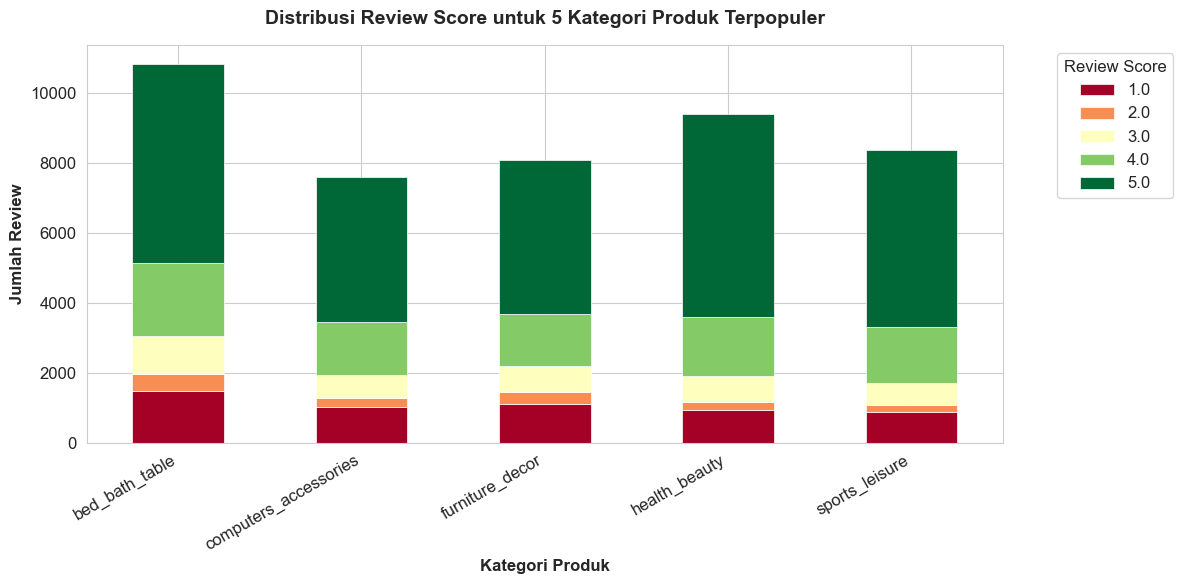

In [69]:
# Visualisasi 2b: Distribusi Skor Review berdasarkan Top Kategori
top5_cats = category_orders.head(5)['product_category_name_english'].values
top5_data = main_df[main_df['product_category_name_english'].isin(top5_cats)]

fig, ax = plt.subplots(figsize=(12, 6))
review_by_cat = top5_data.groupby(['product_category_name_english', 'review_score']).size().unstack(fill_value=0)
review_by_cat.plot(kind='bar', stacked=True, ax=ax, 
                   colormap='RdYlGn', edgecolor='white', linewidth=0.5)

ax.set_title('Distribusi Review Score untuk 5 Kategori Produk Terpopuler', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Kategori Produk', fontsize=12, fontweight='bold')
ax.set_ylabel('Jumlah Review', fontsize=12, fontweight='bold')
ax.legend(title='Review Score', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Analisis Pertanyaan 2:**
- **Kategori terpopuler** berdasarkan jumlah pesanan adalah "bed_bath_table" (perlengkapan kamar & mandi), diikuti "health_beauty" dan "sports_leisure".
- **Kategori dengan pendapatan tertinggi** sedikit berbeda, dengan "health_beauty" menghasilkan pendapatan yang kompetitif meskipun bukan yang paling banyak dipesan.
- Terdapat **korelasi kuat antara jumlah pesanan dan total pendapatan**, namun kategori seperti "computers_accessories" dan "watches_gifts" memiliki average harga yang lebih tinggi sehingga revenue per item lebih besar.
- Dari sisi kualitas, **distribusi review score** menunjukkan bahwa mayoritas pelanggan memberikan rating 5 (sangat puas) untuk semua kategori terpopuler.

## Analisis Lanjutan: RFM Analysis

RFM (Recency, Frequency, Monetary) Analysis adalah teknik segmentasi pelanggan berdasarkan perilaku pembelian mereka. Teknik ini mengelompokkan pelanggan berdasarkan tiga faktor:
- **Recency (R):** Berapa hari sejak terakhir kali pelanggan melakukan pembelian.
- **Frequency (F):** Berapa kali pelanggan melakukan transaksi.
- **Monetary (M):** Berapa total pengeluaran pelanggan.

Tujuannya adalah untuk mengidentifikasi pelanggan terbaik (high-value customers) dan segmen pelanggan lainnya.

In [70]:
# Analisis RFM
# Atur tanggal referensi sebagai hari setelah pembelian terakhir
reference_date = main_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f'Reference date: {reference_date}')

# Hitung metrik RFM per pembeli
rfm_df = main_df.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('price', 'sum')
).reset_index()

print(f'\nTotal unique customers: {len(rfm_df)}')
print(f'\nRFM Statistics:')
rfm_df[['recency', 'frequency', 'monetary']].describe()

Reference date: 2018-08-30 15:00:37

Total unique customers: 93358

RFM Statistics:


,recency,frequency,monetary
count,93358.000000,93358.000000,93358.000000
mean,237.941773,1.033420,141.621480
std,152.591453,0.209097,215.694014
min,1.000000,1.000000,0.850000
25%,114.000000,1.000000,47.650000
50%,219.000000,1.000000,89.730000
75%,346.000000,1.000000,154.737500
max,714.000000,15.000000,13440.000000


In [71]:
# Buat skor RFM menggunakan kuartil
# Untuk Recency: semakin kecil semakin baik, jadi kita reverse skoring-nya
rfm_df['r_score'] = pd.qcut(rfm_df['recency'], q=4, labels=[4, 3, 2, 1])
rfm_df['f_score'] = pd.qcut(rfm_df['frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
rfm_df['m_score'] = pd.qcut(rfm_df['monetary'], q=4, labels=[1, 2, 3, 4])

# Buat komposit skor RFM
rfm_df['rfm_score'] = rfm_df['r_score'].astype(str) + rfm_df['f_score'].astype(str) + rfm_df['m_score'].astype(str)

# Definisikan segmen pembeli berdasarkan skor RFM
def rfm_segment(row):
    r = int(row['r_score'])
    f = int(row['f_score'])
    m = int(row['m_score'])
    
    if r >= 3 and f >= 3 and m >= 3:
        return 'Best Customers'
    elif r >= 3 and f >= 2:
        return 'Loyal Customers'
    elif r >= 3 and m >= 3:
        return 'Big Spenders'
    elif r >= 3:
        return 'Recent Customers'
    elif f >= 3:
        return 'Frequent Buyers'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost Customers'
    elif r <= 2:
        return 'At Risk'
    else:
        return 'Others'

rfm_df['segment'] = rfm_df.apply(rfm_segment, axis=1)

print('=== Customer Segments ===')
segment_counts = rfm_df['segment'].value_counts()
print(segment_counts)

=== Customer Segments ===
segment
Frequent Buyers     23188
Loyal Customers     23035
Best Customers      12135
Lost Customers      11960
At Risk             11363
Recent Customers     5916
Big Spenders         5761
Name: count, dtype: int64


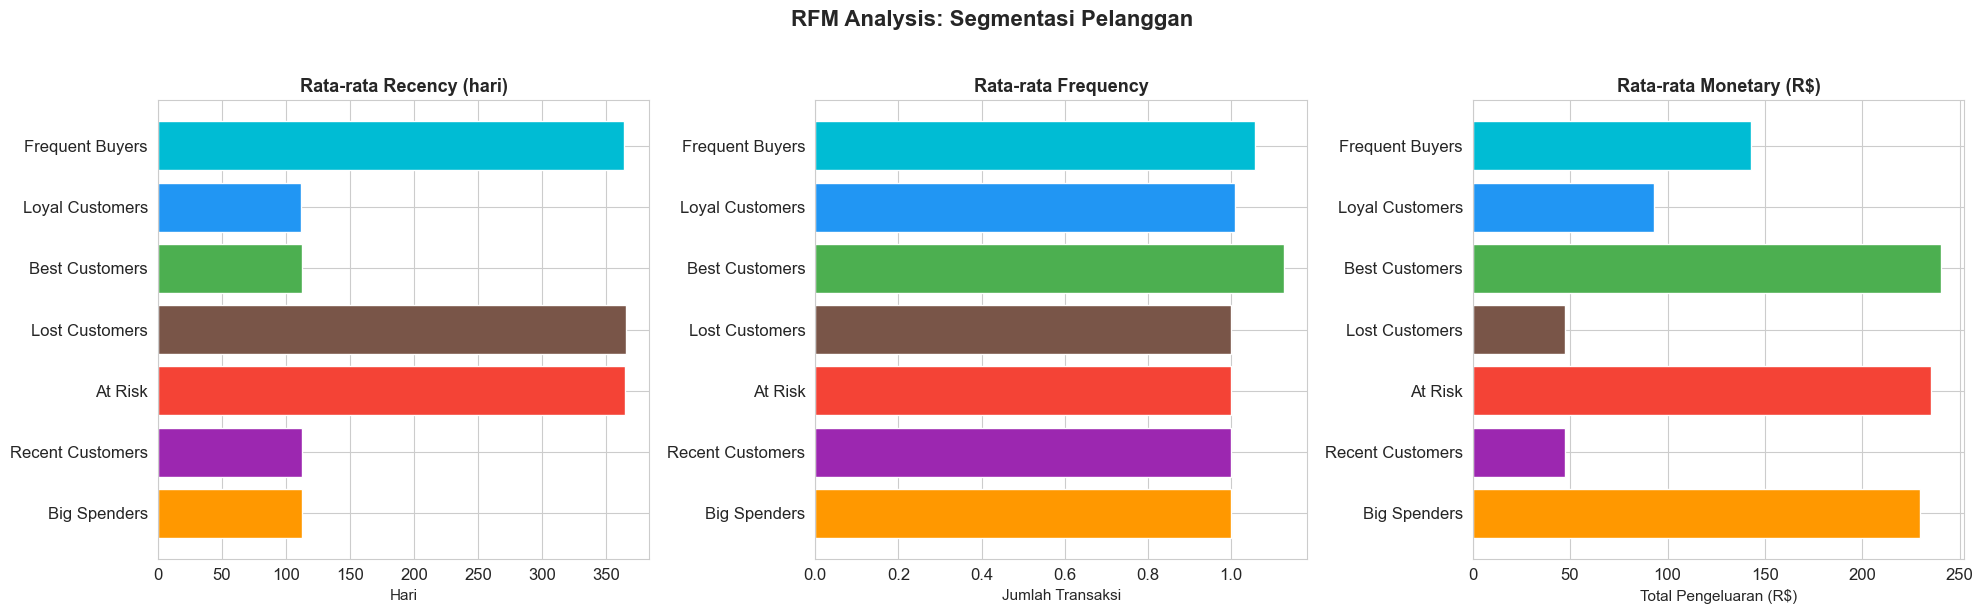

In [72]:
# Visualisasi: Distribusi Segmen RFM
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Definisikan warna konsisten untuk segmen
segment_colors = {
    'Best Customers': '#4CAF50',
    'Loyal Customers': '#2196F3',
    'Big Spenders': '#FF9800',
    'Recent Customers': '#9C27B0',
    'Frequent Buyers': '#00BCD4',
    'At Risk': '#F44336',
    'Lost Customers': '#795548',
    'Others': '#9E9E9E'
}

# 1. Distribusi Recency berdasarkan segmen
segment_summary = rfm_df.groupby('segment').agg(
    count=('customer_unique_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean')
).sort_values('count', ascending=False)

colors = [segment_colors.get(s, '#9E9E9E') for s in segment_summary.index]

axes[0].barh(segment_summary.index[::-1], segment_summary['avg_recency'].values[::-1], 
             color=colors[::-1], edgecolor='white')
axes[0].set_title('Rata-rata Recency (hari)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hari', fontsize=11)

axes[1].barh(segment_summary.index[::-1], segment_summary['avg_frequency'].values[::-1], 
             color=colors[::-1], edgecolor='white')
axes[1].set_title('Rata-rata Frequency', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Jumlah Transaksi', fontsize=11)

axes[2].barh(segment_summary.index[::-1], segment_summary['avg_monetary'].values[::-1], 
             color=colors[::-1], edgecolor='white')
axes[2].set_title('Rata-rata Monetary (R$)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Total Pengeluaran (R$)', fontsize=11)

plt.suptitle('RFM Analysis: Segmentasi Pelanggan', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

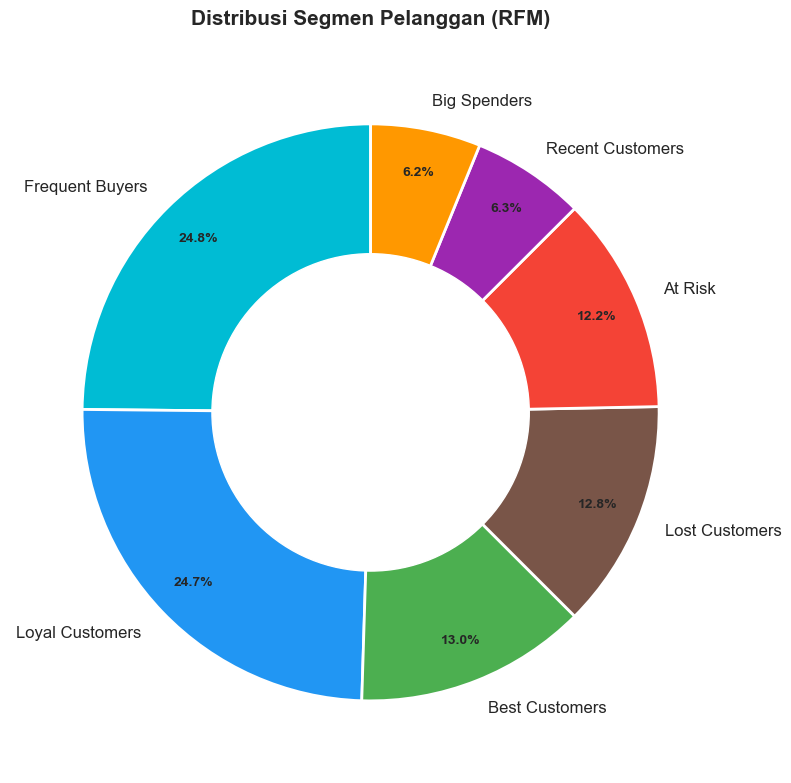


=== Detail Segmen Pelanggan ===


,jumlah_pelanggan,avg_recency,avg_frequency,avg_monetary
segment,,,,
Frequent Buyers,23188,364.11,1.06,143.05
Loyal Customers,23035,111.55,1.01,93.27
Best Customers,12135,112.77,1.13,240.37
Lost Customers,11960,365.67,1.00,47.21
At Risk,11363,364.64,1.00,235.23
Recent Customers,5916,112.73,1.00,47.29
Big Spenders,5761,112.65,1.00,229.40


In [73]:
# Visualisasi: Diagram Bulat untuk Distribusi Segmen
fig, ax = plt.subplots(figsize=(10, 8))

segment_data = rfm_df['segment'].value_counts()
colors_pie = [segment_colors.get(s, '#9E9E9E') for s in segment_data.index]

wedges, texts, autotexts = ax.pie(
    segment_data.values, 
    labels=segment_data.index,
    autopct='%1.1f%%',
    colors=colors_pie,
    startangle=90,
    pctdistance=0.85,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2)
)

for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

centre_circle = plt.Circle((0, 0), 0.55, fc='white')
ax.add_artist(centre_circle)

ax.set_title('Distribusi Segmen Pelanggan (RFM)', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Print detailed segment summary
print('\n=== Detail Segmen Pelanggan ===')
segment_summary_detail = rfm_df.groupby('segment').agg(
    jumlah_pelanggan=('customer_unique_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean')
).sort_values('jumlah_pelanggan', ascending=False).round(2)

segment_summary_detail

**Insight RFM Analysis:**
- Mayoritas pelanggan termasuk dalam segmen "Recent Customers" dan "At Risk", menunjukkan bahwa banyak pelanggan melakukan pembelian baru-baru ini namun dengan frekuensi rendah.
- Segmen "Best Customers" (recency rendah, frekuensi tinggi, monetary tinggi) merupakan segmen yang paling berharga dan perlu dipertahankan.
- Segmen "Lost Customers" memiliki recency tinggi dan frekuensi rendah, menandakan mereka sudah lama tidak bertransaksi.
- Sebagian besar pelanggan hanya melakukan 1 kali pembelian (frequency = 1), menunjukkan pentingnya strategi retensi pelanggan.
- Segmen "Big Spenders" memiliki nilai monetary tinggi meskipun frekuensi pembelian tidak terlalu tinggi, cocok untuk strategi upselling.

## Conclusion

### Kesimpulan Pertanyaan 1: Tren Jumlah Pesanan dan Total Pendapatan per Bulan

Berdasarkan analisis tren bulanan, ditemukan bahwa:
- E-commerce ini mengalami **pertumbuhan yang pesat** dari September 2016 hingga November 2017, dengan jumlah pesanan meningkat secara konsisten.
- Total pendapatan berkorelasi positif dengan jumlah pesanan, menunjukkan bahwa pertumbuhan didorong oleh **volume transaksi** lebih dari kenaikan harga.
- Terdapat **pola musiman** terutama lonjakan di bulan November (kemungkinan pengaruh Black Friday) dan penurunan di awal tahun.
- Pola mingguan menunjukkan **hari kerja lebih aktif** dibandingkan akhir pekan, memberikan insight bahwa promo di hari kerja mungkin lebih efektif.

### Kesimpulan Pertanyaan 2: Kategori Produk Terpopuler dan Revenue Tertinggi

Berdasarkan analisis kategori produk:
- **bed_bath_table, health_beauty, dan sports_leisure** adalah tiga kategori teratas berdasarkan jumlah pesanan.
- Kategori dengan pendapatan tertinggi tidak selalu sesuai dengan yang terpopuler karena faktor **perbedaan harga rata-rata** per kategori.
- Kategori seperti **computers_accessories** dan **watches_gifts** memiliki harga rata-rata lebih tinggi sehingga memberikan kontribusi revenue signifikan meskipun volume pesanan lebih rendah.
- Distribusi review score menunjukkan **tingkat kepuasan tinggi** di semua kategori terpopuler, dengan mayoritas review di score 4-5.

### Kesimpulan RFM Analysis

- Segmentasi pelanggan mengungkapkan bahwa platform ini masih dalam fase **akuisisi pelanggan baru** dengan mayoritas pelanggan melakukan hanya 1 pembelian.
- Perlu strategi **customer retention** yang lebih agresif untuk meningkatkan frequency pembelian.
- Pelanggan "Best Customers" perlu mendapat perhatian khusus melalui program loyalitas.
- Segmen "At Risk" dan "Lost Customers" bisa dikembalikan dengan kampanye re-engagement yang ditargetkan.